In [1]:
import math
import numpy as np
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import norm
from patsy import dmatrices
import statsmodels.graphics.tsaplots as tsa
from matplotlib import pyplot as plt
from statsmodels.tools.numdiff import approx_hess1, approx_hess2, approx_hess3
import scipy.optimize as opt
import pandas as pd

In [2]:
class GaussianHMM(GenericLikelihoodModel):
    #endog:Yt; exog: X list of emission; k: #state; covariate:corvariate list of transtion matrix;
    #length: list of mutlti time serial data length, e.g. [15,22,30]; extra_params_names: name of parameters
    def __init__(self, endog, exog, k_regimes=2, covariate = None , length=None,loglike=None, score=None, hessian=None,
                 missing='none', extra_params_names=None, **kwds):
        super(GaussianHMM, self).__init__(endog=endog, exog=exog, loglike=loglike, score=score,
                                         hessian=hessian, missing=missing,
                                         extra_params_names=extra_params_names, kwds=kwds)
        #Initialize all variable

        self.y = np.array(self.endog)
        self.k_regimes = k_regimes
        if covariate is not None:
            self.covariate = np.array(covariate)
        if length is not None:
            self.length = np.array(length)
        else:
            self.length = None
        
        # 1 x (k_regimes-1) proxy of initial state probability matrix
        self.initial_state_matrix = np.ones([1, self.k_regimes-1])/k_regimes

        #k_regimes x corvariate.shape[1] size matrix of regime specific self-recurrent regression coefficients
        self.covariate_beta_matrix = np.ones([self.k_regimes, self.covariate.shape[1] ])

        # k x (k-2) matrix of psuedo transition probabilities which can range from -inf to +inf during
        # optimization. Initialized to 1.0/k-2
        if self.k_regimes>2:
            self.q_matrix = np.ones([self.k_regimes,(self.k_regimes-2)])*(1.0/ (self.k_regimes-2) )

        #k_regimes x exog.shape[1] size matrix of regime specific regression coefficients
        self.beta_matrix = np.ones([self.k_regimes, self.exog.shape[1]])

        #The regime wise matrix of Poisson means. These would be updated during the optimization
        # loop
        self.mu_matrix = []

        #The state specific variance.
        self.sigma = np.ones([self.k_regimes,1])

        # (t-1) x k x k matrix of the real Markov transition probabilities which will be calculated from
        # the q-matrix using a standardization technique. Initialized to 1.0/k
        self.gamma_matrix = np.ones([self.exog.shape[0]-1, self.k_regimes, self.k_regimes])*(1.0/self.k_regimes)

        # The Markov state probabilities. Also referred to as pi. but we'll use delta since pi is
        # often used to refer to the mean
        self.delta_matrix = np.ones([self.exog.shape[0],self.k_regimes])*(1.0/self.k_regimes)

        #A very tiny number (machine specific). Used by the LL function.
        self.EPS = np.MachAr().eps

        #Optimization iteration counter
        self.iter_num=0

        #The vector of initial values for all the parameters, beta and q, that the optimizer will
        # optimize
        self.start_params = self.beta_matrix.flatten()
        self.start_params = np.append(self.start_params, self.initial_state_matrix.flatten())
        self.start_params = np.append(self.start_params, self.covariate_beta_matrix.flatten())
        self.start_params = np.append(self.start_params, self.sigma.flatten())

        if k_regimes>2:
            self.start_params = np.append(self.start_params, self.q_matrix.flatten())

        self.ll_history = np.zeros([1,1])
        self.params_history = np.zeros([1,len(self.start_params)])
        self.MAE_history = np.zeros([1,1])

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeobs(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_gaussian_means()

        # Compute the GP1 dispersion parameter
        #self.compute_GP1_alpha()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Sort beta_matrix, covariate_beta_matrix, delta_matrix, gamma_matrix and mu_matrix with k_state's emission intercept in ascending order 
        # using selection sort.
        self.sort()

        #Decode state path
        self.decode()
    
        #compute state specific MAE
        MAE = self.compute_mae()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))) + ' MAE=' + str(MAE) )

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)
        self.MAE_history = np.append(self.MAE_history, np.array([MAE]).reshape([1,1]), axis = 0)

        #Return the negated array of  log-likelihood values
        return -ll

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeopt(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_gaussian_means()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Sort beta_matrix, covariate_beta_matrix, delta_matrix, gamma_matrix and mu_matrix with k_state's emission intercept in ascending order 
        # using selection sort.
        self.sort()

        #Decode state path
        self.decode()
    
        #compute state specific MAE
        MAE = self.compute_mae()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))) + ' MAE=' + str(MAE) )

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)
        self.MAE_history = np.append(self.MAE_history, np.array([MAE]).reshape([1,1]), axis = 0)


        #Return the negated array of  log-likelihood values
        return -ll.sum()

    # Reconstitute the q and beta matrices from the current values of all the params
    def reconstitute_parameter_matrices(self, params):
        index = 0

        self.beta_matrix = params[ : self.k_regimes*self.exog.shape[1] ]
        self.beta_matrix = self.beta_matrix.reshape([self.k_regimes, self.exog.shape[1] ]) 
        index = index + self.k_regimes*self.exog.shape[1]
        
        self.initial_state_matrix = params[index : index + self.k_regimes - 1 ]
        self.initial_state_matrix = self.initial_state_matrix.reshape([1, self.k_regimes-1])
        index = index + self.k_regimes - 1

        self.covariate_beta_matrix = params[index : index + self.k_regimes * self.covariate.shape[1]]
        self.covariate_beta_matrix = self.covariate_beta_matrix.reshape([self.k_regimes, self.covariate.shape[1] ])
        index = index + self.k_regimes * self.covariate.shape[1]
            
        if self.k_regimes>2:
            self.q_matrix = params[index : index + self.k_regimes*(self.k_regimes-2)]
            self.q_matrix = self.q_matrix.reshape([self.k_regimes, (self.k_regimes-2)])
            index = index + self.k_regimes * self.k_regimes
        
        self.sigma = params[index : index + self.k_regimes]
        self.sigma = self.sigma.reshape([self.k_regimes,1])

        


    # Build the regime wise matrix of Poisson means
    def compute_regime_specific_gaussian_means(self):
        self.mu_matrix = []
        '''for k in range(1, self.k_regimes):
            self.beta_matrix[k][0] += np.exp(self.beta_matrix[k-1][0])'''

        for j in range(self.k_regimes):
            #Fetch the regression coefficients vector corresponding to the jth regime
            beta_j = self.beta_matrix[j]

            #Compute the Poisson mean and variance
            mu_j = self.exog.dot(beta_j)
 

            if len(self.mu_matrix) == 0:
                self.mu_matrix = mu_j
            else:
                self.mu_matrix = np.vstack((self.mu_matrix,mu_j))


                
        self.mu_matrix = self.mu_matrix.transpose()
    
    # Build the matrix of Markov transition probabilities by computing self-recurrent and non-recurrent state probabilities
    def compute_markov_transition_probabilities(self):
        
        # t x k recurrent matrix compute state k transition to itself in every time t
        self.recurrent_matrix = (self.covariate.dot(self.covariate_beta_matrix.transpose()))
        for t in range(self.exog.shape[0]-1):
            for i in range(self.k_regimes):
                for j in range(self.k_regimes):
                    if(i==j):
                        if(self.recurrent_matrix[t][j]>=709):
                            self.recurrent_matrix[t][j]=709
                        self.gamma_matrix[t][i][j] = math.exp(self.recurrent_matrix[t][j]) /( 1 + math.exp(self.recurrent_matrix[t][j]) )

        # If k=2, there's no need to use q_matrix
        if(self.k_regimes==2):
            for t in range(self.exog.shape[0]-1):
                for i in range(self.k_regimes):
                    for j in range(self.k_regimes):
                        if(i!=j):
                            self.gamma_matrix[t][i][j] = 1 - self.gamma_matrix[t][i][i]
        else:
            for t in range(self.exog.shape[0]-1):
                #Using  q to compute transtion probability which is not self-recurrent
                for i in range(self.k_regimes):
                    denom = 1
                    count = 0
                    for r in range(self.k_regimes-2):
                        denom += math.exp(self.q_matrix[i][r])
                        
                    for j in range(self.k_regimes):            
                        if(i==j ):continue
                        else:
                            if(count < self.k_regimes-2):
                                self.gamma_matrix[t][i][j] =( math.exp(self.q_matrix[i][count])/denom)*(1-self.gamma_matrix[t][i][i])
                                count+=1
                            else:
                                self.gamma_matrix[t][i][j] = (1.0/denom)*(1-self.gamma_matrix[t][i][i])

    # Build the (t x k) matrix delta of Markov state probabilities distribution. k state
    # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
    def compute_markov_state_probabilities(self):
        #Compute initial state probability
        denom = 1
        for r in range(self.k_regimes-1):
            if(self.initial_state_matrix[0][r]>709):
                self.initial_state_matrix[0][r] = 709
            denom += math.exp(self.initial_state_matrix[0][r])
            
        for j in range(self.k_regimes-1):
            self.delta_matrix[0][j] = math.exp(self.initial_state_matrix[0][j])/denom
        self.delta_matrix[0][self.k_regimes-1] = 1.0/denom

        #Compute state probabilties in each time t seperately if there's multiple time serial data.
        if(self.length is not None):
            index = 1
            for n in range(len(self.length)):
                for t in range(index, index + self.length[n] - 1):
                    self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])
                index += self.length[n]
                if (index-1) < len(self.y):
                    self.delta_matrix[index-1]= self.delta_matrix[0]
        else:
            for t in range(1, len(self.y)):
                self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])


    # Compute all the log-likelihood values for the Poisson Markov model
    def compute_loglikelihood(self):
        #Init the list of loglikelihhod values, one value for each y observation
        ll = []
        for t in range(len(self.y)):
            prob_y_t = 0
            mu_t = 0
            for j in range(self.k_regimes):
                #To use the law of total probability, uncomment this row and comment out the next
                # two rows

                prob_y_t += norm.pdf(self.y[t], self.mu_matrix[t][j], self.sigma[j] ) * self.delta_matrix[t][j]
                #Calculate the Poisson mean mu_t as an expectation over all Markov state
                # probabilities
                #mu_t += self.mu_matrix[t][j] * self.delta_matrix[t][j]
                #prob_y_t += poisson.pmf(self.y[t], mu_t)

            #This is a bit of a kludge. If the likelihood turns out to be real tiny, fix it to
            # the EPS value for the machine
            if prob_y_t < self.EPS:
                prob_y_t = self.EPS
            #Push the LL into the list of LLs
            ll.append(math.log(prob_y_t))
        ll = np.array(ll)
        return ll
    
    #Decode state path
    def decode(self):
        #decoded state path matrix: t
        self.decode_matrix = np.ones([len(self.y)])
        self.state_specific_mu = np.zeros([len(self.y),1])
        
        for t in range( len(self.y) ):
            max = 0
            state = 0
            for k in range(self.k_regimes):
                if(k == 0):
                    max = self.delta_matrix[t][k]
                    state = state + 1
                else:
                    if(self.delta_matrix[t][k] > max):
                        state = state + 1
                        max = self.delta_matrix[t][k]
            self.decode_matrix[t] = state

        #compute state specific mu
        for t in range( len(self.y) ):
            for k in range(1,self.k_regimes+1):
                if (self.decode_matrix[t] == k):
                    self.state_specific_mu[t] = self.mu_matrix[t][k-1]
    
    #compute state specific MAE
    def compute_mae(self):
        return ((np.abs(self.state_specific_mu.reshape([len(self.y),])-self.y)).mean())


    #Sort beta_matrix, covariate_beta_matrix, delta_matrix, gamma_matrix and mu_matrix with k_state's emission intercept in ascending order 
    # using selection sort.
    def sort(self):
        for i in range(self.k_regimes-1):
            minimum = i
            for j in range(i+1,self.k_regimes):
                if( self.beta_matrix[minimum][0] > self.beta_matrix[j][0] ):
                    minimum = j
            if(minimum != i):
                self.beta_matrix = list(self.beta_matrix)
                self.beta_matrix[minimum], self.beta_matrix[i] =  self.beta_matrix[i], self.beta_matrix[minimum]
                self.beta_matrix = np.array(self.beta_matrix)

                self.covariate_beta_matrix = list(self.covariate_beta_matrix)
                self.covariate_beta_matrix[minimum], self.covariate_beta_matrix[i] = self.covariate_beta_matrix[i], self.covariate_beta_matrix[minimum]
                self.covariate_beta_matrix = np.array(self.covariate_beta_matrix)

                self.sigma = list(self.sigma)
                self.sigma[minimum], self.sigma[i] =  self.sigma[i], self.sigma[minimum]
                self.sigma = np.array(self.sigma)

                self.delta_matrix = list(self.delta_matrix)
                self.mu_matrix = list(self.mu_matrix)

                for t in range(len(self.y)):
                    self.delta_matrix[t][minimum], self.delta_matrix[t][i] =  self.delta_matrix[t][i], self.delta_matrix[t][minimum]
                    self.mu_matrix[t][minimum], self.mu_matrix[t][i] =  self.mu_matrix[t][i], self.mu_matrix[t][minimum]
                self.delta_matrix = np.array(self.delta_matrix)
                self.mu_matrix = np.array(self.mu_matrix)

                self.gamma_matrix = list(self.gamma_matrix) 
                for t in range(len(self.y)-1):
                    self.gamma_matrix[t][minimum][minimum], self.gamma_matrix[t][i][i] = self.gamma_matrix[t][i][i], self.gamma_matrix[t][minimum][minimum]
                    self.gamma_matrix[t][minimum][i], self.gamma_matrix[t][i][minimum] = self.gamma_matrix[t][i][minimum], self.gamma_matrix[t][minimum][i]
                self.gamma_matrix = np.array(self.gamma_matrix)


In [3]:
norm.pdf([1,2], loc = 23, scale= 100)

array([0.00389404, 0.00390242])

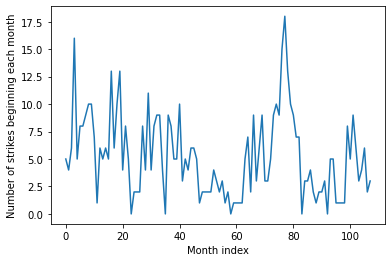

In [4]:
strikes_dataset = sm.datasets.get_rdataset(dataname="StrikeNb", package = "Ecdat")
strikes_data = strikes_dataset.data

#Plot the number of strikes starting each month
plt.xlabel('Month index')
plt.ylabel('Number of strikes beginning each month')
strikes_data['strikes'].plot()
plt.show()

In [5]:
strikes_data['strikes_lag1'] = strikes_data['strikes'].shift(1)
strikes_data = strikes_data.dropna()

def indicator_func(x):
    if x == 0:
        return 1
    else:
        return 0

strikes_data['d1'] = strikes_data['strikes_lag1'].apply(indicator_func)
strikes_data['strikes_adj_lag1']=np.maximum(1,strikes_data['strikes_lag1'])
strikes_data['ln_strike_adj_lag1']=np.log(strikes_data['strikes_adj_lag1']) 

expr = 'strikes ~ output + ln_strike_adj_lag1 + d1'
y_train, x_train = dmatrices(expr, strikes_data, return_type='dataframe')

C:\Users\s9421\AppData\Local\Temp/ipykernel_16696/3195480036.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strikes_data['d1'] = strikes_data['strikes_lag1'].apply(indicator_func)
C:\Users\s9421\AppData\Local\Temp/ipykernel_16696/3195480036.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strikes_data['strikes_adj_lag1']=np.maximum(1,strikes_data['strikes_lag1'])
C:\Users\s9421\AppData\Local\Temp/ipykernel_16696/3195480036.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

In [6]:
cor = 'strikes ~ output + ln_strike_adj_lag1 + d1 '
y, covariate = dmatrices(cor, strikes_data, return_type='dataframe')

In [7]:
k_regimes = 2
extra_params_names = []

for regime_num in range(1, k_regimes):
    for param_name in x_train.columns:
        extra_params_names.append(param_name+'_R'+str(regime_num))

for k in range(k_regimes-1):
    extra_params_names.append('Initial state_'+str(k))

for regime_num in range(k_regimes):
#    extra_params_names.append("Intercept_"+str(regime_num))
    for param_name in covariate.columns:
        extra_params_names.append(param_name+"_"+str(regime_num))
    

#for i in range(k_regimes):
#    for j in range(k_regimes-2):
#        extra_params_names.append('q_'+str(i)+str(j))

In [8]:
gaussian_hmm = GaussianHMM(endog=y_train, exog=x_train, covariate=covariate,
                        k_regimes=k_regimes,length=[len(y_train)],
                        extra_params_names=extra_params_names)
params = gaussian_hmm.start_params           
             
res=opt.minimize(gaussian_hmm.nloglikeopt,params, method='Nelder-Mead')

#poisson_hmm_results = gaussian_hmm.fit(method='bfgs', maxiter=400)

ITER=1 ll=961.417287475299 MAE=3.2362011709719303
ITER=2 ll=955.3499879622153 MAE=3.208769021439221
ITER=3 ll=961.3957375921698 MAE=3.2364210074205286
ITER=4 ll=951.6118954617955 MAE=3.191716626716789
ITER=5 ll=961.1475868727514 MAE=3.2356837877943607
ITER=6 ll=955.6455349301906 MAE=3.2362011709719303
ITER=7 ll=961.3986375499708 MAE=3.2362011709719303
ITER=8 ll=952.1329762664609 MAE=3.2362011709719303
ITER=9 ll=961.147898706261 MAE=3.2362011709719303
ITER=10 ll=961.417287475299 MAE=3.2362011709719303
ITER=11 ll=961.417287475299 MAE=3.2362011709719303
ITER=12 ll=961.417287475299 MAE=3.2362011709719303
ITER=13 ll=961.417287475299 MAE=3.2362011709719303
ITER=14 ll=961.417287475299 MAE=3.2362011709719303
ITER=15 ll=961.417287475299 MAE=3.2362011709719303
ITER=16 ll=961.417287475299 MAE=3.2362011709719303
ITER=17 ll=961.417287475299 MAE=3.2362011709719303
ITER=18 ll=961.417287475299 MAE=3.2362011709719303
ITER=19 ll=925.0373876006998 MAE=3.2362011709719303
ITER=20 ll=926.1856229497344 MAE=3

In [11]:
gaussian_hmm_results = gaussian_hmm.fit(method='bfgs', maxiter=400)

ITER=3803 ll=961.417287475299 MAE=3.2362011709719303
ITER=3804 ll=961.417287475299 MAE=3.2362011709719303
ITER=3805 ll=961.4169391755337 MAE=3.236199331698382
ITER=3806 ll=961.4176357727099 MAE=3.2362030102454797
ITER=3807 ll=961.4172862166953 MAE=3.2362011842840266
ITER=3808 ll=961.4172887338973 MAE=3.2362011576598344
ITER=3809 ll=961.4167504234874 MAE=3.236198477230616
ITER=3810 ll=961.4178245199325 MAE=3.236203864713247
ITER=3811 ll=961.4172721002112 MAE=3.236201086082382
ITER=3812 ll=961.4173028502692 MAE=3.236201255861479
ITER=3813 ll=961.4169573026511 MAE=3.2362011709719303
ITER=3814 ll=961.4176176455768 MAE=3.2362011709719303
ITER=3815 ll=961.4172863923466 MAE=3.2362011709719303
ITER=3816 ll=961.4172885582459 MAE=3.2362011709719303
ITER=3817 ll=961.4167832332516 MAE=3.2362011709719303
ITER=3818 ll=961.41779171011 MAE=3.2362011709719303
ITER=3819 ll=961.4172721201699 MAE=3.2362011709719303
ITER=3820 ll=961.4173028303104 MAE=3.2362011709719303
ITER=3821 ll=961.417287475299 MAE=3.2

c:\ProgramData\Anaconda3\envs\tensorflow-python38\lib\site-packages\statsmodels\base\model.py:592: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\ProgramData\Anaconda3\envs\tensorflow-python38\lib\site-packages\statsmodels\base\model.py:2694: UserWarning: df_model + k_constant differs from nparams
  warnings.warn("df_model + k_constant differs from nparams")
c:\ProgramData\Anaconda3\envs\tensorflow-python38\lib\site-packages\statsmodels\base\model.py:2696: UserWarning: df_resid differs from nobs - nparams
  warnings.warn("df_resid differs from nobs - nparams")


In [12]:
gaussian_hmm_results.summary()

ITER=10843 ll=255.27053116566364 MAE=2.395583000775916


<class 'statsmodels.iolib.summary.Summary'>
"""
                             GaussianHMM Results                              
==============================================================================
Dep. Variable:                strikes   Log-Likelihood:                -255.27
Model:                    GaussianHMM   AIC:                             518.5
Method:            Maximum Likelihood   BIC:                             529.2
Date:                Fri, 22 Jul 2022                                         
Time:                        12:43:48                                         
No. Observations:                 107                                         
Df Residuals:                     103                                         
Df Model:                           3                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.1364        nan        nan        nan         nan         nan
output                   26.1258        nan        nan        nan         nan         nan
ln_strike_adj_lag1        2.0559        nan        nan        nan         nan         nan
d1                        2.9377        nan        nan        nan         nan         nan
Intercept_R1              1.1751        nan        nan        nan         nan         nan
output_R1                -7.8645        nan        nan        nan         nan         nan
ln_strike_adj_lag1_R1     1.3622        nan        nan        nan         nan         nan
d1_R1                     0.2748        nan        nan        nan         nan         nan
Initial state_0         -17.3375        nan        nan        nan         nan         nan
Intercept_0             -61.0268        nan        nan        nan         nan         nan
output_0                 26.0268        nan        nan        nan         nan         nan
ln_strike_adj_lag1_0     67.4237        nan        nan        nan         nan         nan
d1_0                     62.1027        nan        nan        nan         nan         nan
Intercept_1              -0.0300        nan        nan        nan         nan         nan
output_1                  4.7900        nan        nan        nan         nan         nan
ln_strike_adj_lag1_1      0.0182        nan        nan        nan         nan         nan
d1_1                     13.2899        nan        nan        nan         nan         nan
par0                      3.2577        nan        nan        nan         nan         nan
par1                      0.7955        nan        nan        nan         nan         nan
=========================================================================================
"""

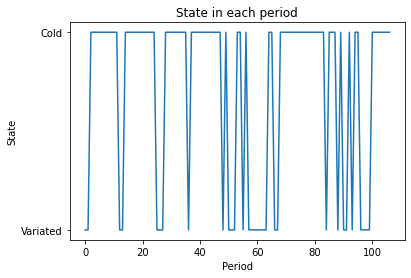

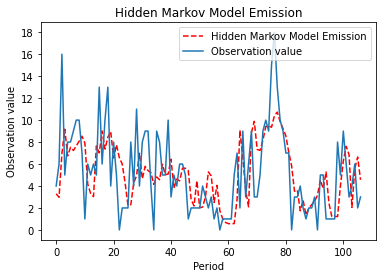

In [13]:
from matplotlib.ticker import MaxNLocator

#Plot the state each month
plt.xlabel('Period')
plt.ylabel('State')
plt.title("State in each period")
plt.yticks([1,2,3],['Variated','Cold','Hot'])
plt.plot(range(107),gaussian_hmm.decode_matrix)
plt.show()

#Plot the mu_2 each month

plt.plot(range(107),gaussian_hmm.state_specific_mu,'--r',label="Hidden Markov Model Emission")


#Plot the number of strikes starting each month
plt.xlabel('Period')
plt.ylabel('Observation value')
plt.title("Hidden Markov Model Emission")
plt.plot(range(len(y)), y,label = "Observation value")
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.show()